# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Data Set Dataset](https://www.kaggle.com/datasets/ajitjha01/sales-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/ajitjha01/sales-dataset/Data Set.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Data Set.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Product_Name,Category,Region,Customer_Type,Payment_Method,Quantity,Unit_Price,Total_Sales
0,1001,2023-08-06,2023,8,3,Laptop,Electronics,Chennai,Premimum,Card,2,50353,100706
1,1002,2022-06-06,2022,6,2,Headphones,Electronics,Delhi,New,UPI,2,2008,4016
2,1004,2023-06-20,2023,6,2,Watch,Other,Pune,Premimum,Card,2,10072,20144
3,1005,2024-11-03,2024,11,4,Mobile Case,Other,Pune,New,UPI,2,920,1840
4,1005,2023-01-13,2023,1,1,Mobile Case,Other,Pune,New,UPI,2,920,1840


## last Five row

In [4]:
df.tail()

,Order_ID,Order_Date,Year,Month,Quarter,Product_Name,Category,Region,Customer_Type,Payment_Method,Quantity,Unit_Price,Total_Sales
1495,1495,2026-05-11,2026,5,2,Mobile Case,Other,Bangalore,Returning,Card,5,745,3725
1496,1496,2026-05-12,2026,5,2,Tablet,Electronics,Mumbai,Premimum,COD,1,30973,30973
1497,1497,2026-05-13,2026,5,2,Book,Books,Mumbai,New,UPI,5,756,3780
1498,1498,2026-05-14,2026,5,2,Backpack,Fashion,Pune,Premimum,Card,1,966,966
1499,1499,2026-05-15,2026,5,2,Smartwatch,Electronics,Hyderabad,Premimum,UPI,1,13343,13343


## Shape of our dataset

In [5]:
df.shape

(1500, 13)

## List out all columns

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Product_Name',
       'Category', 'Region', 'Customer_Type', 'Payment_Method', 'Quantity',
       'Unit_Price', 'Total_Sales'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Order_ID           int64
Order_Date        object
Year               int64
Month              int64
Quarter            int64
Product_Name      object
Category          object
Region            object
Customer_Type     object
Payment_Method    object
Quantity           int64
Unit_Price         int64
Total_Sales        int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        1500 non-null   int64 
 1   Order_Date      1500 non-null   object
 2   Year            1500 non-null   int64 
 3   Month           1500 non-null   int64 
 4   Quarter         1500 non-null   int64 
 5   Product_Name    1500 non-null   object
 6   Category        1500 non-null   object
 7   Region          1500 non-null   object
 8   Customer_Type   1500 non-null   object
 9   Payment_Method  1500 non-null   object
 10  Quantity        1500 non-null   int64 
 11  Unit_Price      1500 non-null   int64 
 12  Total_Sales     1500 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 152.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Year              0
Month             0
Quarter           0
Product_Name      0
Category          0
Region            0
Customer_Type     0
Payment_Method    0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(3)

## Summary

In [11]:
df.describe()

,Order_ID,Year,Month,Quarter,Quantity,Unit_Price,Total_Sales
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000
mean,1199.016000,2023.671333,6.201333,2.406000,2.30200,11107.217333,18813.820667
std,119.963169,1.306056,3.516206,1.131084,1.28889,17420.364118,28381.173834
min,1001.000000,2022.000000,1.000000,1.000000,1.00000,100.000000,129.000000
25%,1100.000000,2023.000000,3.000000,1.000000,1.00000,747.000000,1824.000000
50%,1192.500000,2023.000000,6.000000,2.000000,2.00000,3098.000000,5190.000000
75%,1284.250000,2025.000000,9.000000,3.000000,3.00000,12992.000000,25138.000000
max,1499.000000,2026.000000,12.000000,4.000000,5.00000,69296.000000,137032.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

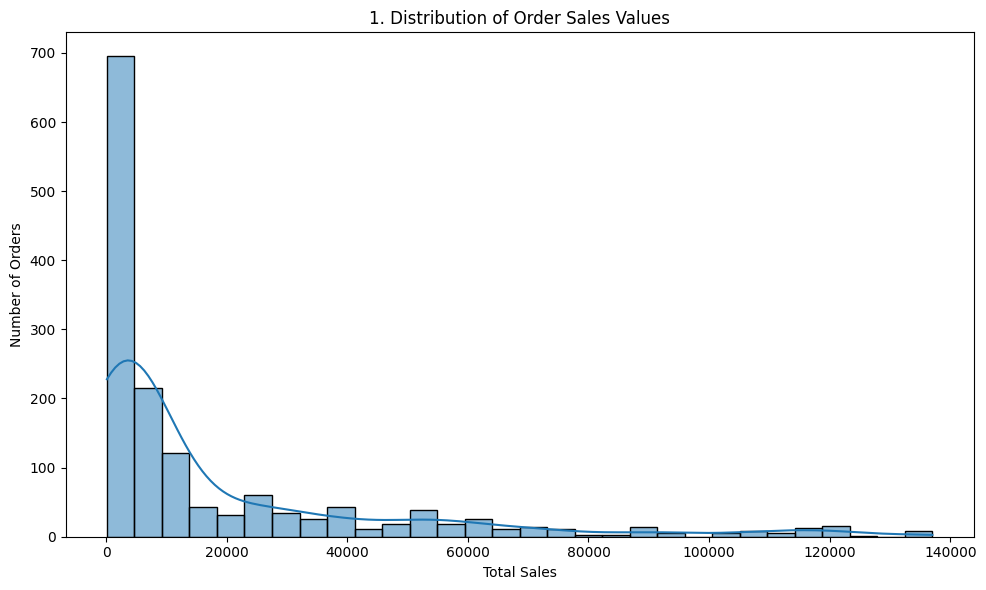

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Total_Sales', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Order Sales Values')
plt.xlabel('Total Sales')
plt.ylabel('Number of Orders')
show_fig()
plot_no += 1

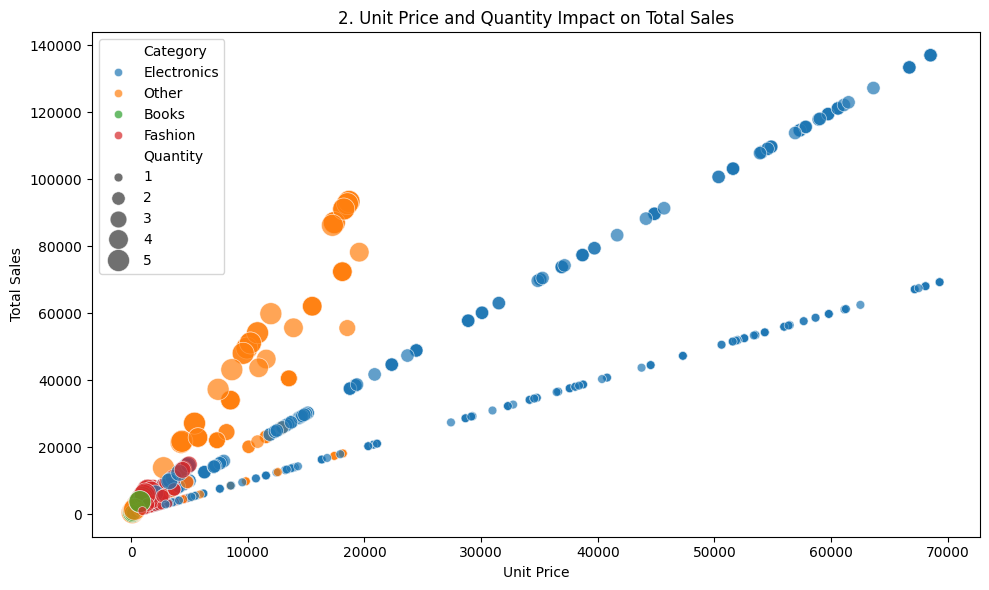

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Unit_Price', y='Total_Sales', hue='Category', size='Quantity', sizes=(40, 250), alpha=0.7)
plt.title(f'{plot_no}. Unit Price and Quantity Impact on Total Sales')
plt.xlabel('Unit Price')
plt.ylabel('Total Sales')
show_fig()
plot_no += 1

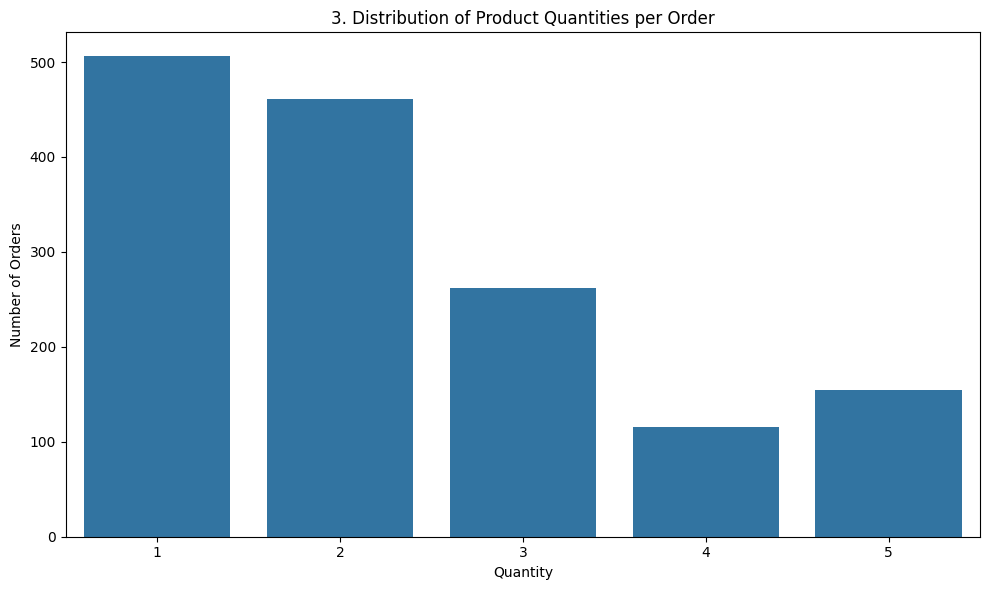

In [15]:
fig = plt.figure(figsize=(10,6))
quantity_order = sorted(df['Quantity'].dropna().unique())
sns.countplot(data=df, x='Quantity', order=quantity_order)
plt.title(f'{plot_no}. Distribution of Product Quantities per Order')
plt.xlabel('Quantity')
plt.ylabel('Number of Orders')
show_fig()
plot_no += 1

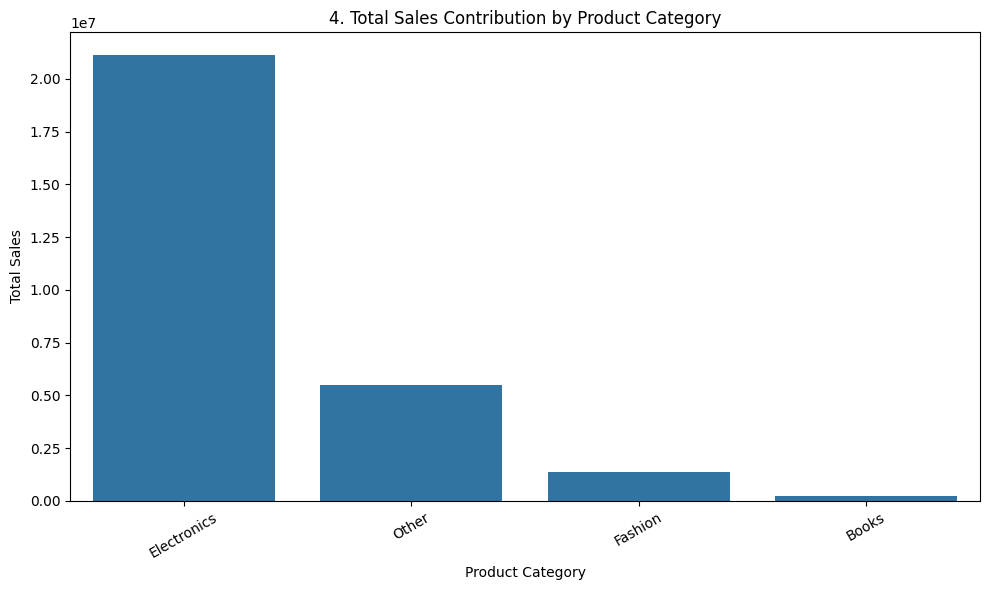

In [16]:
fig = plt.figure(figsize=(10,6))
category_sales = df.groupby('Category', as_index=False)['Total_Sales'].sum().sort_values('Total_Sales', ascending=False)
sns.barplot(data=category_sales, x='Category', y='Total_Sales')
plt.title(f'{plot_no}. Total Sales Contribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

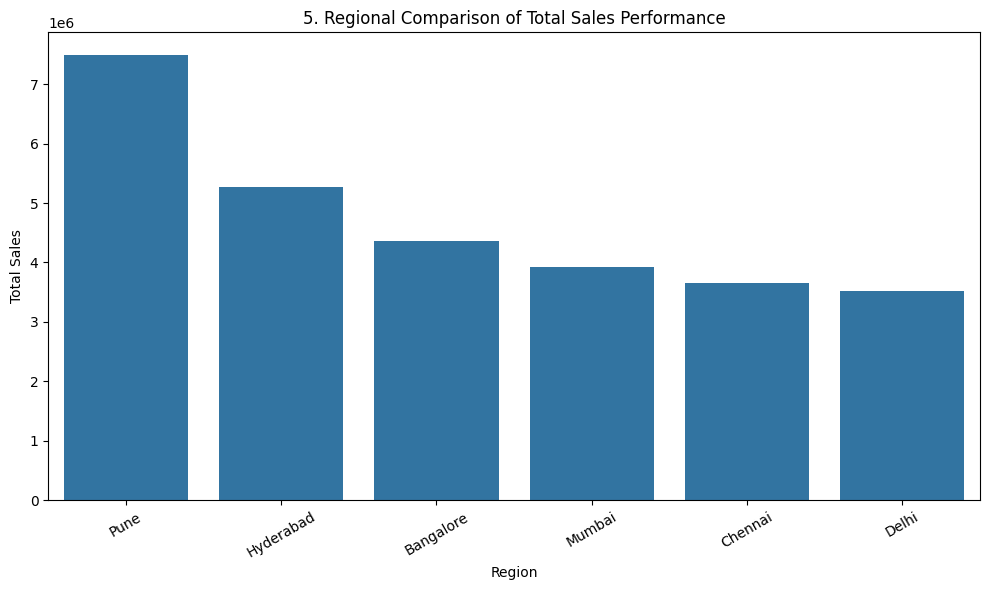

In [17]:
fig = plt.figure(figsize=(10,6))
region_sales = df.groupby('Region', as_index=False)['Total_Sales'].sum().sort_values('Total_Sales', ascending=False)
sns.barplot(data=region_sales, x='Region', y='Total_Sales')
plt.title(f'{plot_no}. Regional Comparison of Total Sales Performance')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

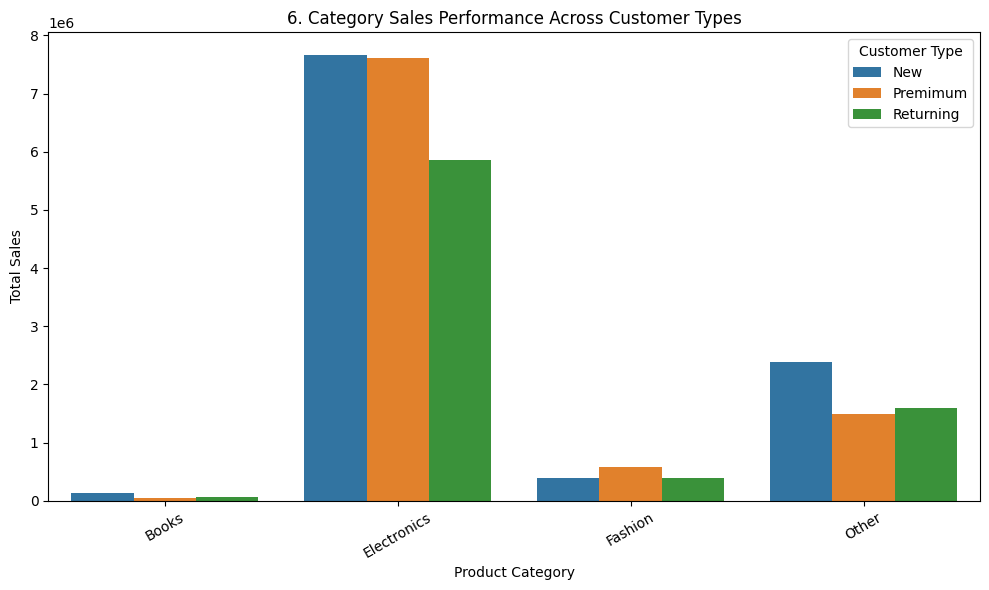

In [18]:
fig = plt.figure(figsize=(10,6))
category_customer_sales = df.groupby(['Category', 'Customer_Type'], as_index=False)['Total_Sales'].sum()
sns.barplot(data=category_customer_sales, x='Category', y='Total_Sales', hue='Customer_Type')
plt.title(f'{plot_no}. Category Sales Performance Across Customer Types')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.legend(title='Customer Type')
show_fig()
plot_no += 1

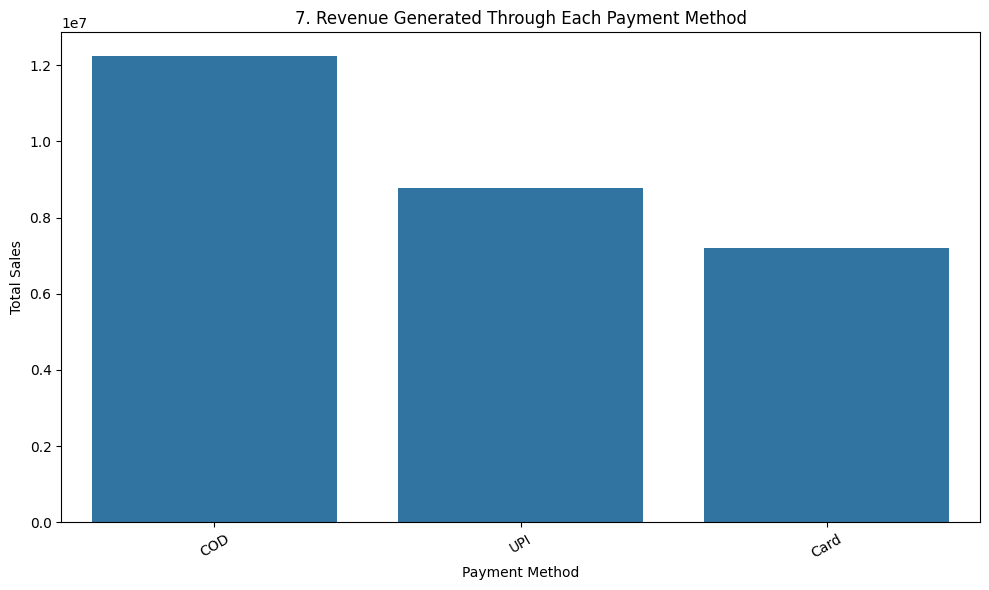

In [19]:
fig = plt.figure(figsize=(10,6))
payment_sales = df.groupby('Payment_Method', as_index=False)['Total_Sales'].sum().sort_values('Total_Sales', ascending=False)
sns.barplot(data=payment_sales, x='Payment_Method', y='Total_Sales')
plt.title(f'{plot_no}. Revenue Generated Through Each Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

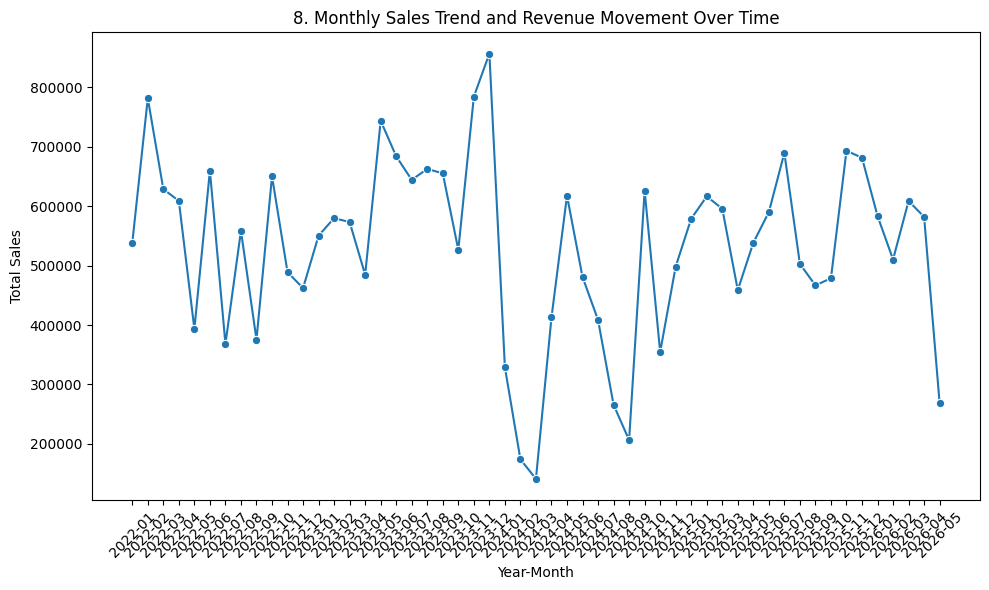

In [20]:
fig = plt.figure(figsize=(10,6))
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales'].sum().reset_index()
monthly_sales['Order_Date'] = monthly_sales['Order_Date'].astype(str)
sns.lineplot(data=monthly_sales, x='Order_Date', y='Total_Sales', marker='o')
plt.title(f'{plot_no}. Monthly Sales Trend and Revenue Movement Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

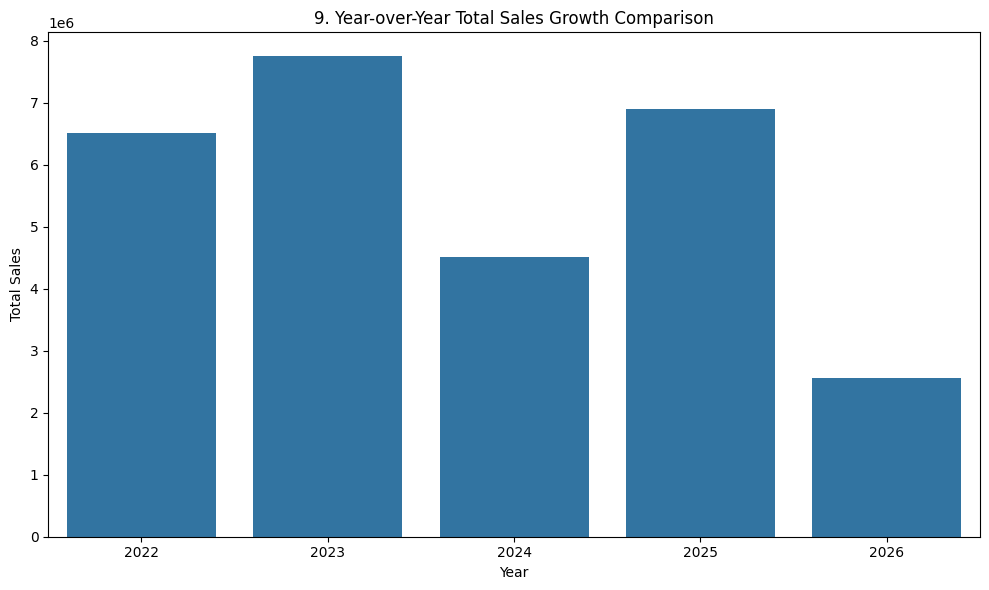

In [21]:
fig = plt.figure(figsize=(10,6))
yearly_sales = df.groupby('Year', as_index=False)['Total_Sales'].sum().sort_values('Year')
sns.barplot(data=yearly_sales, x='Year', y='Total_Sales')
plt.title(f'{plot_no}. Year-over-Year Total Sales Growth Comparison')
plt.xlabel('Year')
plt.ylabel('Total Sales')
show_fig()
plot_no += 1

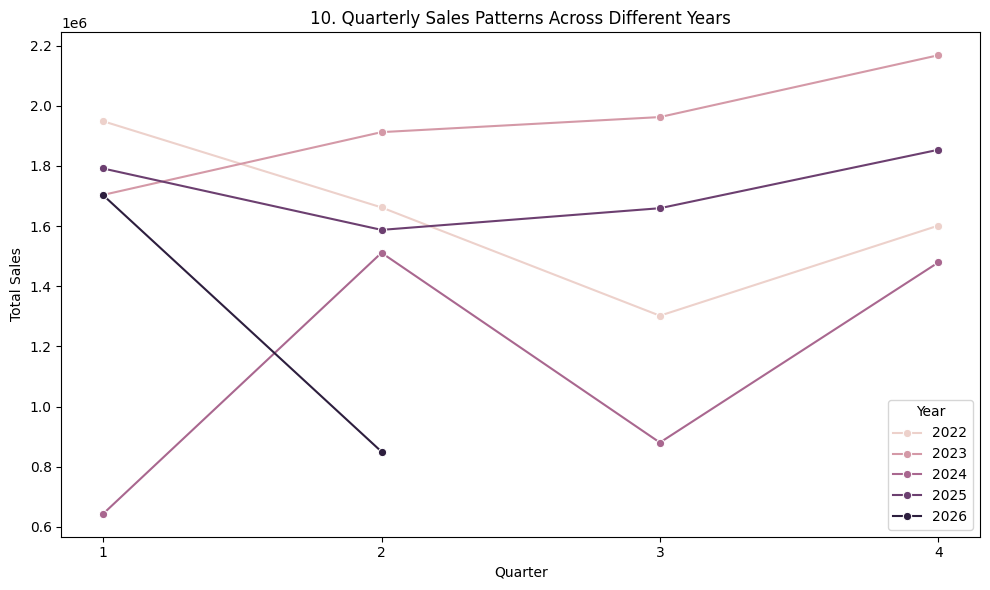

In [22]:
fig = plt.figure(figsize=(10,6))
quarterly_sales = df.groupby(['Year', 'Quarter'], as_index=False)['Total_Sales'].sum()
sns.lineplot(data=quarterly_sales, x='Quarter', y='Total_Sales', hue='Year', marker='o')
plt.title(f'{plot_no}. Quarterly Sales Patterns Across Different Years')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks([1, 2, 3, 4])
plt.legend(title='Year')
show_fig()
plot_no += 1

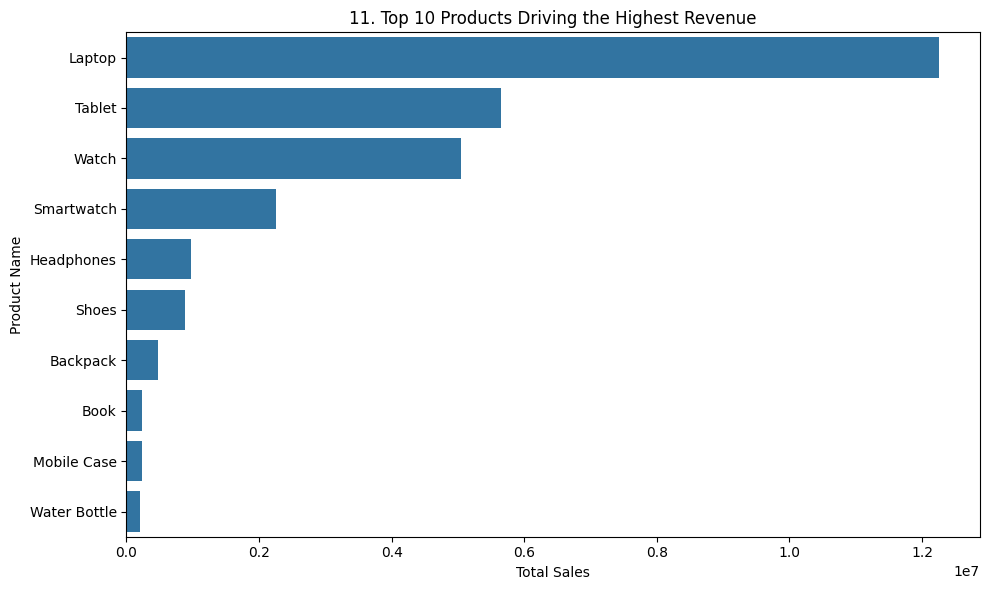

In [23]:
fig = plt.figure(figsize=(10,6))
product_sales = df.groupby('Product_Name', as_index=False)['Total_Sales'].sum().nlargest(10, 'Total_Sales')
sns.barplot(data=product_sales, x='Total_Sales', y='Product_Name')
plt.title(f'{plot_no}. Top 10 Products Driving the Highest Revenue')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
show_fig()
plot_no += 1

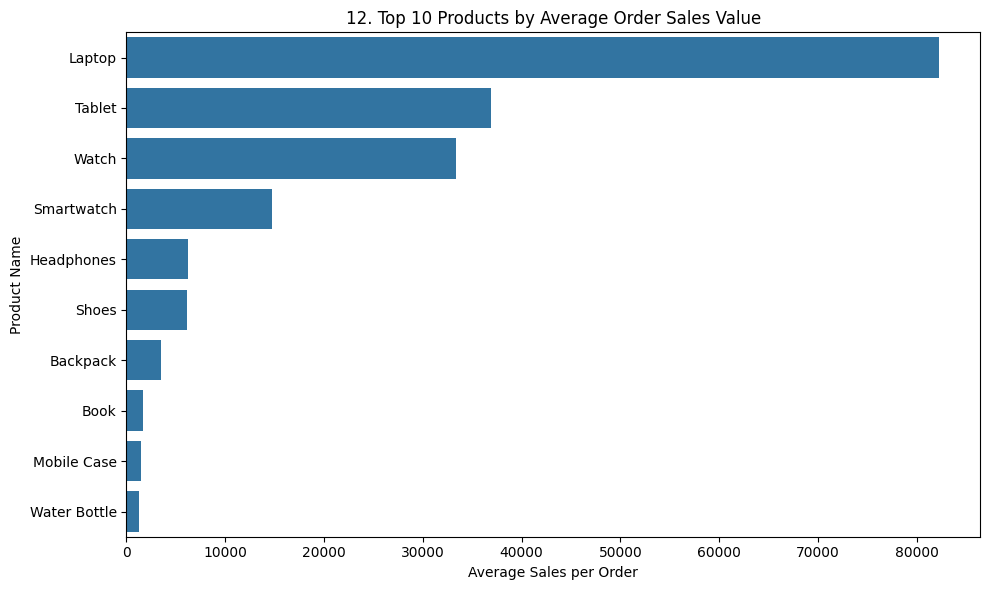

In [24]:
fig = plt.figure(figsize=(10,6))
product_average_sales = df.groupby('Product_Name', as_index=False)['Total_Sales'].mean().nlargest(10, 'Total_Sales')
sns.barplot(data=product_average_sales, x='Total_Sales', y='Product_Name')
plt.title(f'{plot_no}. Top 10 Products by Average Order Sales Value')
plt.xlabel('Average Sales per Order')
plt.ylabel('Product Name')
show_fig()
plot_no += 1

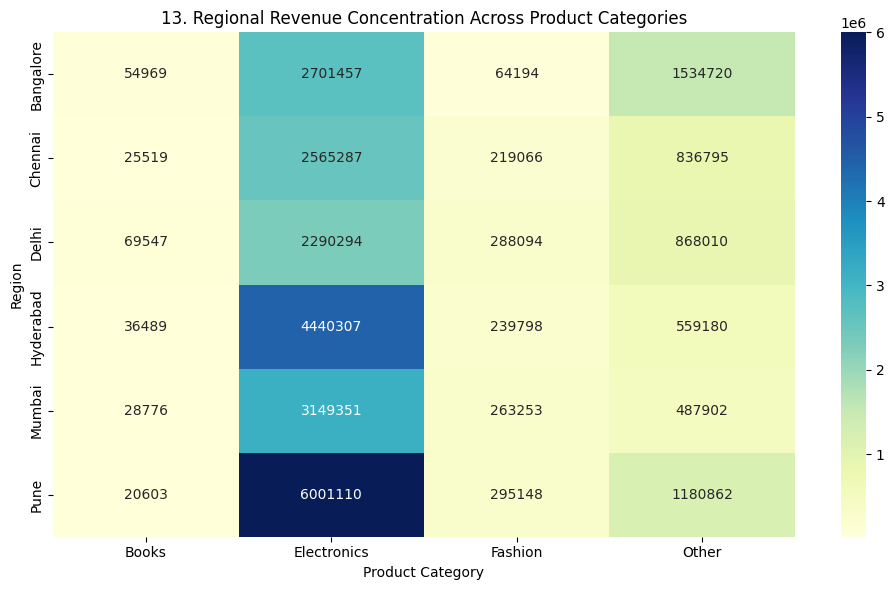

In [25]:
fig = plt.figure(figsize=(10,6))
region_category_sales = df.pivot_table(index='Region', columns='Category', values='Total_Sales', aggfunc='sum', fill_value=0)
sns.heatmap(region_category_sales, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title(f'{plot_no}. Regional Revenue Concentration Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Region')
show_fig()
plot_no += 1

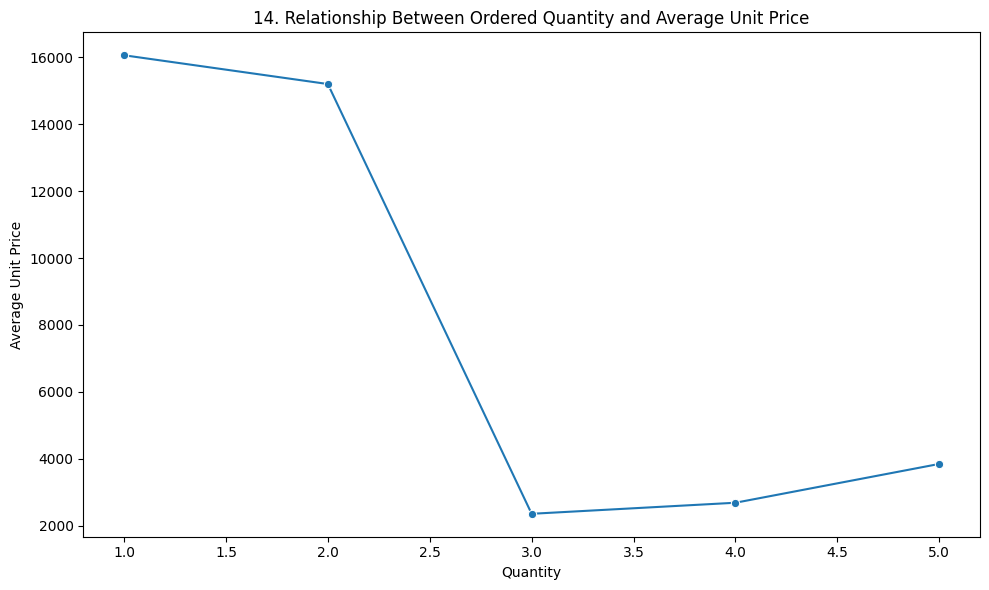

In [26]:
fig = plt.figure(figsize=(10,6))
quantity_price = df.groupby('Quantity', as_index=False)['Unit_Price'].mean().sort_values('Quantity')
sns.lineplot(data=quantity_price, x='Quantity', y='Unit_Price', marker='o')
plt.title(f'{plot_no}. Relationship Between Ordered Quantity and Average Unit Price')
plt.xlabel('Quantity')
plt.ylabel('Average Unit Price')
show_fig()
plot_no += 1

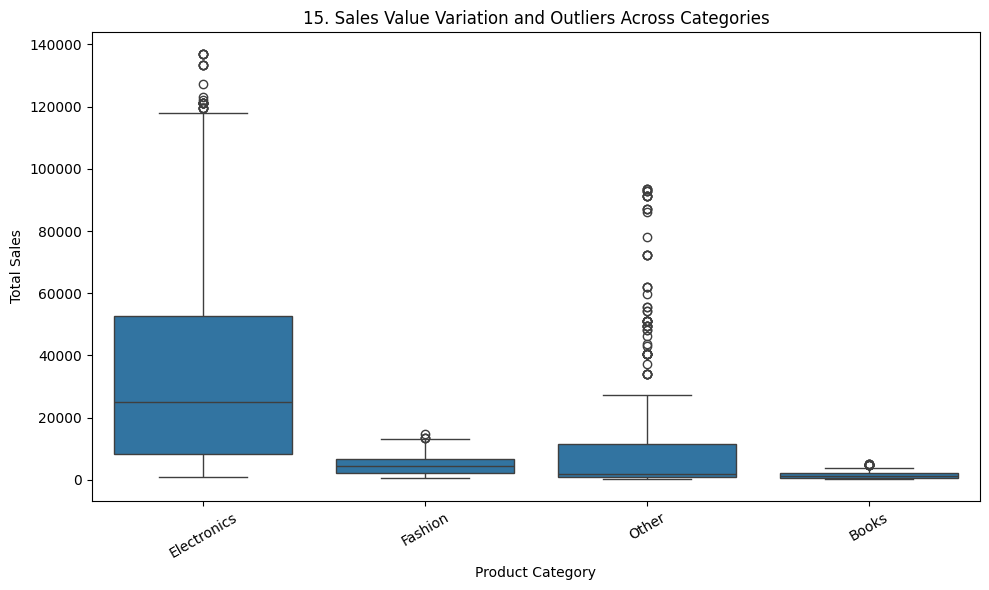

In [27]:
fig = plt.figure(figsize=(10,6))
category_order = df.groupby('Category')['Total_Sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Category', y='Total_Sales', order=category_order)
plt.title(f'{plot_no}. Sales Value Variation and Outliers Across Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

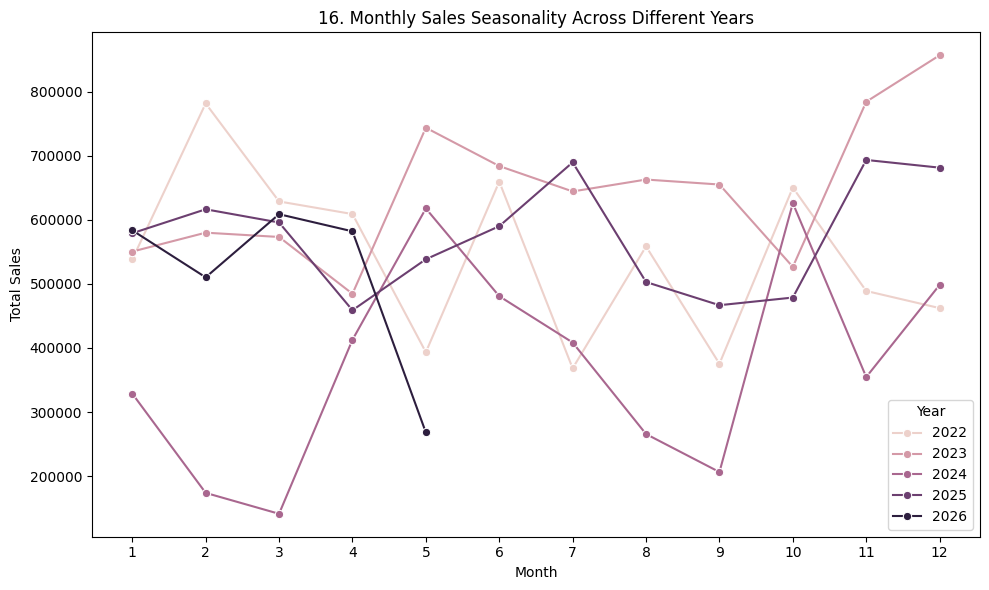

In [28]:
fig = plt.figure(figsize=(10,6))
month_year_sales = df.groupby(['Year', 'Month'], as_index=False)['Total_Sales'].sum()
sns.lineplot(data=month_year_sales, x='Month', y='Total_Sales', hue='Year', marker='o')
plt.title(f'{plot_no}. Monthly Sales Seasonality Across Different Years')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.legend(title='Year')
show_fig()
plot_no += 1

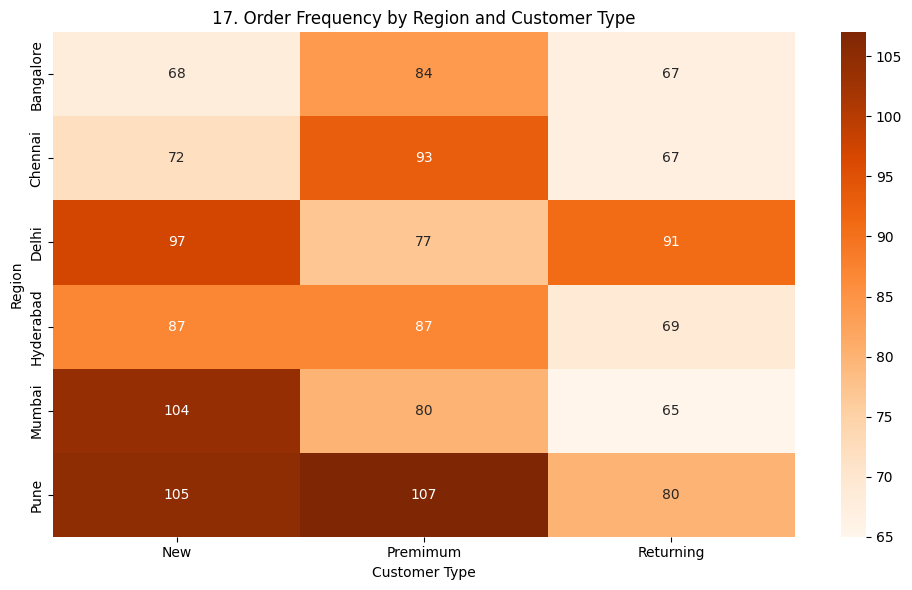

In [29]:
fig = plt.figure(figsize=(10,6))
region_customer_orders = df.pivot_table(index='Region', columns='Customer_Type', values='Order_ID', aggfunc='count', fill_value=0)
sns.heatmap(region_customer_orders, annot=True, fmt='.0f', cmap='Oranges')
plt.title(f'{plot_no}. Order Frequency by Region and Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Region')
show_fig()
plot_no += 1

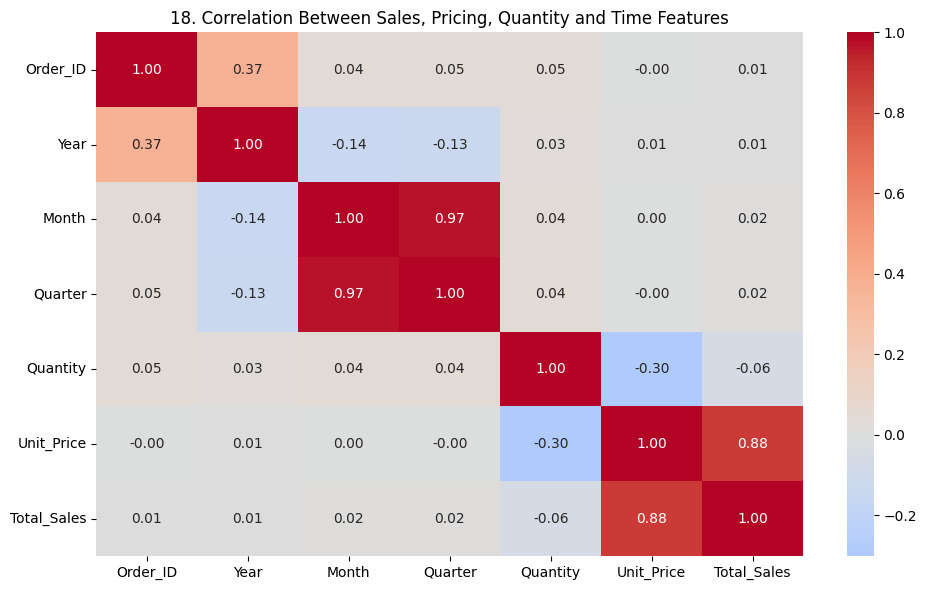

In [30]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Between Sales, Pricing, Quantity and Time Features')
show_fig()
plot_no += 1

# Model Training

## select the target column

In [31]:
target = 'Total_Sales'

## remove identifier, date and target columns

In [32]:
X = df.drop(columns=[target, 'Order_ID', 'Order_Date'], errors='ignore')
y = df[target]

## select numerical and categorical columns

In [33]:
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns

## create numerical preprocessing

In [34]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## create categorical preprocessing

In [35]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## combine numerical and categorical preprocessing

In [36]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## create the gradient boosting regression model

In [37]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

## split the dataset into training and testing data

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## train the model

In [39]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Month', 'Quarter', 'Quantity', 'Unit_Price'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Product_Name', 'Category', 'Region', 'Customer_Type',
       'Payment_Method'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

## predict total sales

In [40]:
y_pred = model.predict(X_test)

## calculate model performance

In [41]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

## print model performance

In [42]:
print(f"Model Accuracy (R² Score): {r2 * 100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Model Accuracy (R² Score): 99.93%
Mean Absolute Error: 432.91
Root Mean Squared Error: 726.07


## plot actual and predicted total sales

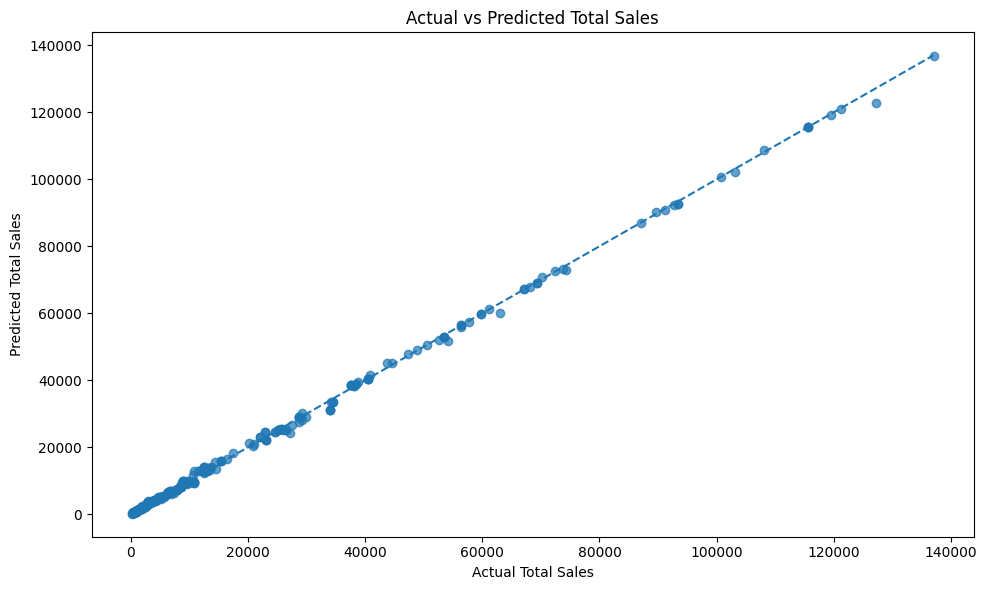

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel('Actual Total Sales')
plt.ylabel('Predicted Total Sales')
plt.title('Actual vs Predicted Total Sales')
plt.tight_layout()
plt.show()